# Stage 2: Data Preparation and GARCH Volatility

**Project:** Does GARCH information improve forecasts of implied volatility?

Stage 2 assembles a clean matched VIX / S&P 500 dataset, documents its
time-series properties, and estimates a baseline GARCH(1,1) so that model-based
conditional volatility can be compared against option-implied volatility.

*No forecasting is performed at this stage.*

## 1. Data sources and sample

| Series | Source | File | Sample |
|---|---|---|---|
| CBOE Volatility Index (VIX), daily close | **CBOE (official)** | `VIX_History.csv` | 2012-01-03 – 2026-08-21 |
| S&P 500 Composite, daily close | Yahoo Finance (`^GSPC`) | `sp500_raw.csv` | 2012-01-03 – 2026-08-21 |
| VIX, daily close *(validation only)* | Yahoo Finance (`^VIX`) | `vix_raw.csv` | 2012-01-03 – 2026-08-21 |

**Why two sources.** CBOE publishes the complete VIX history free of charge but
does not publish S&P 500 index history, so no single free provider covers both
series. Fernandes et al. (2014) state no data source at all. Wen et al. (2024)
use OptionMetrics IvyDB and Tonghuashun — both paid subscriptions, and both
options databases rather than index sources. Liu, Guo & Qiao (2015, §4.1)
confront the same constraint directly, take both series from Yahoo Finance, and
report that comparing Yahoo's VIX against CBOE's shows "only very minor
differences for a few days."

We take the VIX from CBOE directly, and use the Yahoo VIX solely to replicate
Liu et al.'s validation exercise on our own sample (Section 1.3). The S&P 500
comes from Yahoo because no free official alternative exists.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:,.4f}".format)

# Locate the data folder wherever the notebook is run from
CANDIDATES = [Path("data/raw"), Path("."), Path("stage2/data/raw"), Path("/content")]
DATA_DIR = next((p for p in CANDIDATES if (p / "sp500_raw.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "sp500_raw.csv not found in any of: " + ", ".join(str(p) for p in CANDIDATES))
print("Reading data from:", DATA_DIR.resolve())

START, END = "2012-01-01", "2026-08-21"

Reading data from: /root/stage2/data


### 1.1 Load the raw files

In [2]:
def load_yf(filename, colname):
    """Read a yfinance CSV export and return a single close-price column.

    yfinance writes a three-row header (Price / Ticker / Date); rows 1 and 2 are
    metadata and are skipped so that row 0 supplies the column names.
    """
    df = pd.read_csv(DATA_DIR / filename, index_col=0, parse_dates=True, skiprows=[1, 2])
    df.index.name = "Date"
    return df[["Close"]].rename(columns={"Close": colname})


def load_cboe(filename, colname):
    """Read CBOE's official VIX_History.csv (DATE, OPEN, HIGH, LOW, CLOSE)."""
    df = pd.read_csv(DATA_DIR / filename, parse_dates=["DATE"]).set_index("DATE")
    df.index.name = "Date"
    return df[["CLOSE"]].rename(columns={"CLOSE": colname})


vix_cboe = load_cboe("VIX_History.csv", "VIX")        # primary VIX series
vix_yf   = load_yf("vix_raw.csv",   "VIX_YF")         # validation only
sp_hist  = load_yf("sp500_raw.csv", "SP500")          # S&P 500 prices

for name, s in [("VIX (CBOE)", vix_cboe), ("VIX (Yahoo)", vix_yf), ("S&P 500", sp_hist)]:
    print(f"{name:14s} {s.index.min().date()} -> {s.index.max().date()}   N = {len(s):,}")

VIX (CBOE)     1990-01-02 -> 2026-09-01   N = 9,263
VIX (Yahoo)    1990-01-02 -> 2026-08-21   N = 9,228
S&P 500        1990-01-02 -> 2026-08-21   N = 9,227


### 1.2 Calendar audit

The two calendars are compared explicitly before merging. An inner join would
discard mismatches silently, and the brief asks for missing observations to be
*checked* rather than simply dropped.

In [3]:
win_cboe = vix_cboe.loc[START:END]
win_yf   = vix_yf.loc[START:END]
win_sp   = sp_hist.loc[START:END]

print(f"Observations in {START} .. {END}")
print(f"  VIX (CBOE) : {len(win_cboe):,}")
print(f"  VIX (Yahoo): {len(win_yf):,}")
print(f"  S&P 500    : {len(win_sp):,}")

vix_not_sp = win_cboe.index.difference(win_sp.index)
sp_not_vix = win_sp.index.difference(win_cboe.index)
print(f"\nDates with VIX but no S&P 500 close : {len(vix_not_sp)}")
print(f"Dates with S&P 500 but no VIX      : {len(sp_not_vix)}")
print(f"\nFirst few VIX-only dates: {[str(d.date()) for d in vix_not_sp[:6]]}")

print("\nInternal missing values:",
      {"VIX_CBOE": int(vix_cboe['VIX'].isna().sum()),
       "SP500": int(sp_hist['SP500'].isna().sum())})
print("Duplicate index entries:",
      {"VIX_CBOE": int(vix_cboe.index.duplicated().sum()),
       "SP500": int(sp_hist.index.duplicated().sum())})

Observations in 2012-01-01 .. 2026-08-21
  VIX (CBOE) : 3,712
  VIX (Yahoo): 3,681
  S&P 500    : 3,680

Dates with VIX but no S&P 500 close : 32
Dates with S&P 500 but no VIX      : 0

First few VIX-only dates: ['2022-05-30', '2022-06-20', '2022-07-04', '2022-09-05', '2022-11-24', '2023-01-16']

Internal missing values: {'VIX_CBOE': 0, 'SP500': 0}
Duplicate index entries: {'VIX_CBOE': 0, 'SP500': 0}


**Finding.** CBOE reports a VIX close on 32 dates within the sample on which the
NYSE cash market was closed — US market holidays such as Independence Day,
Thanksgiving, Memorial Day and Juneteenth, concentrated from 2022 onward. These
are genuine index values, not data errors: VIX is calculated from SPX option
quotes, which are disseminated in sessions that do not always coincide with
regular equity trading hours.

Because a matched S&P 500 return cannot be formed on a day the equity market did
not trade, these dates are excluded by the inner join below. No dates carry an
S&P 500 close without a corresponding VIX value, and neither series contains
internal missing values or duplicate dates.

### 1.3 Validating the Yahoo VIX against CBOE

Replicating Liu et al. (2015, §4.1) on our own sample. This matters because the
S&P 500 series has to come from Yahoo — CBOE does not publish it — so the
provider's accuracy needs to be established rather than assumed.

In [4]:
cmp = win_yf.join(vix_cboe, how="inner").round(2)
diff = (cmp["VIX_YF"] - cmp["VIX"]).abs().round(2)

print(f"Common dates compared      : {len(cmp):,}")
print(f"Identical to 2 dp          : {(diff == 0).sum():,}  ({100*(diff==0).mean():.2f}%)")
print(f"Differing by more than 0.01: {(diff > 0.01).sum()}")
print(f"Mean absolute difference   : {diff.mean():.6f}")
print(f"Pearson correlation        : {cmp['VIX_YF'].corr(cmp['VIX']):.8f}")

print("\nAll dates differing by more than 0.01:")
print(cmp.assign(abs_diff=diff)[diff > 0.01]
         .sort_values("abs_diff", ascending=False)
         .to_string(float_format=lambda v: f"{v:.2f}"))

Common dates compared      : 3,681
Identical to 2 dp          : 3,672  (99.76%)
Differing by more than 0.01: 9
Mean absolute difference   : 0.001236
Pearson correlation        : 0.99997393

All dates differing by more than 0.01:
            VIX_YF   VIX  abs_diff
Date                              
2026-02-06   20.37 17.76      2.61
2014-10-15   25.27 26.25      0.98
2014-12-09   15.35 14.89      0.46
2014-12-01   14.16 14.29      0.13
2014-08-29   12.09 11.98      0.11
2021-08-11   16.17 16.06      0.11
2014-12-05   11.89 11.82      0.07
2021-10-01   21.10 21.15      0.05
2014-12-03   12.50 12.47      0.03


**Finding.** The two providers agree exactly, to two decimal places, on 99.76% of
the 3,681 common dates; only nine days differ by more than 0.01, and the
correlation is 0.99997. This reproduces Liu et al.'s conclusion on a more recent
sample and supports their judgement that Yahoo's data quality "should not be a
concern."

The one material exception is **2026-02-06**, where Yahoo reports 20.37 against
CBOE's 17.76 — a 15% gap. The surrounding sequence identifies which is correct:

In [5]:
context = sp_hist.copy()
context["ret"] = 100 * np.log(context["SP500"]).diff()
print(context.loc["2026-02-04":"2026-02-10"]
             .join(cmp[["VIX_YF", "VIX"]])
             .rename(columns={"VIX": "VIX_CBOE"})
             .to_string(float_format=lambda v: f"{v:.2f}"))

             SP500   ret  VIX_YF  VIX_CBOE
Date                                      
2026-02-04 6882.72 -0.51   18.64     18.64
2026-02-05 6798.40 -1.23   21.77     21.77
2026-02-06 6932.30  1.95   20.37     17.76
2026-02-09 6964.82  0.47   17.36     17.36
2026-02-10 6941.81 -0.33   17.79     17.79


The S&P 500 rose 1.95% on 2026-02-06, a move that should produce a sharp fall in
implied volatility. CBOE's path — 21.77 → 17.76 → 17.36 — is consistent with that
rally. Yahoo's 20.37 sits out of line with both its neighbours and the return
series. CBOE is correct here and Yahoo carries a bad print.

Nine erroneous observations in 3,681 would not materially affect the results, but
since CBOE publishes the VIX for free there is no reason to accept even that.
**The CBOE series is used as the VIX throughout.** Yahoo is retained only for the
S&P 500, which CBOE does not publish — exactly the position Liu et al. document.

### 1.4 Log returns

Daily continuously compounded S&P 500 returns, in percent:

$$r_t = 100\,[\ln(P_t) - \ln(P_{t-1})]$$

Returns are computed on the **full** price history *before* the sample is
truncated to 2012. Slicing first would leave the first in-sample return undefined
and waste an observation; computing first means the 2012-01-03 return is measured
against the 2011-12-30 close, as it should be.

In [6]:
sp_hist["ret"] = 100 * np.log(sp_hist["SP500"]).diff()
sp_hist.loc["2011-12-28":"2012-01-05"]

,SP500,ret
Date,,
2011-12-28,"1,249.6400",-1.2557
2011-12-29,"1,263.0200",1.0650
2011-12-30,"1,257.6000",-0.4301
2012-01-03,"1,277.0601",1.5355
2012-01-04,"1,277.3000",0.0188
2012-01-05,"1,281.0601",0.2939


### 1.5 Merge and restrict to the analysis window

In [7]:
df = pd.concat([sp_hist, vix_cboe], axis=1, join="inner").dropna()
df = df.loc[START:END, ["SP500", "VIX", "ret"]]

gaps = df.index.to_series().diff().dt.days

print(f"Analysis sample : {df.index.min().date()} -> {df.index.max().date()}")
print(f"Observations    : {len(df):,}")
print(f"Missing values  : {df.isna().sum().to_dict()}")
print(f"Largest gap between consecutive observations: "
      f"{int(gaps.max())} calendar days, ending {gaps.idxmax().date()}")

Analysis sample : 2012-01-03 -> 2026-08-21
Observations    : 3,680
Missing values  : {'SP500': 0, 'VIX': 0, 'ret': 0}
Largest gap between consecutive observations: 5 calendar days, ending 2012-10-31


The largest gap is five calendar days ending 2012-10-31 — the NYSE closure for
Hurricane Sandy on 29–30 October 2012. This is a genuine market closure rather
than a data fault, so no imputation is applied and the return spanning it is a
true multi-day return.

In [8]:
df.to_csv(DATA_DIR / "stage2_clean.csv")
print(f"Saved {DATA_DIR / 'stage2_clean.csv'}   ({len(df):,} rows)\n")
display(df.head(3))
display(df.tail(3))

Saved stage2_clean.csv   (3,680 rows)



,SP500,VIX,ret
Date,,,
2012-01-03,"1,277.0601",22.9700,1.5355
2012-01-04,"1,277.3000",22.2200,0.0188
2012-01-05,"1,281.0601",21.4800,0.2939


,SP500,VIX,ret
Date,,,
2026-08-19,"7,707.9800",14.8900,0.2107
2026-08-20,"7,641.1602",16.0100,-0.8707
2026-08-21,"7,674.3701",15.1300,0.4337


## 2. Descriptive statistics

Following the format of Fernandes et al. (2014, Table 1): location, dispersion,
the two shape moments, and a formal normality test. Skewness and kurtosis are the
substantive entries here — they are what motivate a conditional-variance model in
the first place, and a plain `.describe()` reports neither.

Kurtosis is reported **unstandardised** (normal = 3), matching Fernandes et al.

In [9]:
from scipy import stats

def describe(s):
    jb_stat, jb_p = stats.jarque_bera(s)
    return {
        "N":        len(s),
        "Mean":     s.mean(),
        "Median":   s.median(),
        "Std. dev": s.std(),
        "Minimum":  s.min(),
        "Maximum":  s.max(),
        "Skewness": stats.skew(s),
        "Kurtosis": stats.kurtosis(s, fisher=False),
        "Jarque-Bera": jb_stat,
    }

desc = pd.DataFrame({
    "VIX":                describe(df["VIX"]),
    "S&P 500 return (%)": describe(df["ret"]),
})
display(desc)

for name, s in [("VIX", df["VIX"]), ("S&P 500 return", df["ret"])]:
    print(f"Jarque-Bera p-value, {name:15s}: {stats.jarque_bera(s)[1]:.3e}")

,VIX,S&P 500 return (%)
N,"3,680.0000","3,680.0000"
Mean,17.7459,0.0491
Median,16.1800,0.0681
Std. dev,6.4710,1.0514
Minimum,9.1400,-12.7652
Maximum,82.6900,9.0895
Skewness,2.8631,-0.6381
Kurtosis,18.9386,19.3136
Jarque-Bera,"43,980.2476","41,057.0054"


Jarque-Bera p-value, VIX            : 0.000e+00
Jarque-Bera p-value, S&P 500 return : 0.000e+00


**Reading the table.**

*VIX* averages 17.75 with a median of 16.18. Mean above median, skewness of
**+2.86**, and a maximum of 82.69 against a minimum of 9.14 all describe the same
shape: VIX sits at a modest level most of the time and occasionally spikes very
hard. The maximum is 16 March 2020. Kurtosis of 18.9 against a normal value of 3
confirms those spikes are far more frequent than a Gaussian would allow.

*S&P 500 returns* average 0.049% per day with a standard deviation of 1.05%.
Skewness is **−0.64** — the mirror image of VIX, since the large moves that drive
volatility up are predominantly falls. Kurtosis of 19.3 is the classic fat-tailed
return distribution: the worst day is −12.77% and the best +9.09%, both far
outside anything a normal distribution with σ = 1.05 would produce.

Jarque–Bera rejects normality for both series with p-values below 10⁻³⁰⁰. Note
that the global float format would print these as `0.0000`, so they are reported
separately in scientific notation.

## 3. Plots

A shared style is applied so every figure in the report reads as one set. Colours
come from a validated categorical palette (blue `#2a78d6`, orange `#eb6834`);
that pair clears colour-vision-deficiency separation with a wide margin, which
matters if the report is printed in greyscale or read by a colourblind examiner.

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#d8d7d2"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT,
    "text.color": INK, "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.alpha": 0.55,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def finish(ax, title, ylabel, xlabel="Year"):
    ax.set_title(title, color=INK, pad=8, loc="left", fontweight="medium")
    ax.set_ylabel(ylabel); ax.set_xlabel(xlabel)
    ax.set_axisbelow(True)
    ax.margins(x=0.01)
    return ax

### Figure 1 — VIX over time

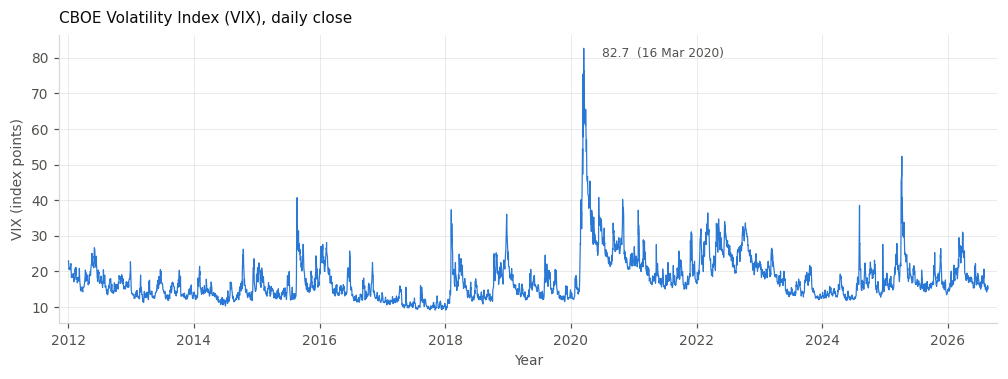

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(df.index, df["VIX"], color=BLUE, linewidth=0.8)
finish(ax, "CBOE Volatility Index (VIX), daily close", "VIX (index points)")

peak = df["VIX"].idxmax()
ax.annotate(f"{df['VIX'].max():.1f}  ({peak:%d %b %Y})",
            xy=(peak, df["VIX"].max()), xytext=(12, -6),
            textcoords="offset points", fontsize=8, color=INK_SOFT)
fig.savefig(FIG_DIR / "fig1_vix.png"); plt.show()

VIX spends most of the sample between roughly 12 and 20, punctuated by sharp,
short-lived spikes: August 2015 (China devaluation), February 2018 (the
"volatilmageddon" VIX-ETP unwind), March 2020 (COVID-19, the sample maximum at
82.69), and 2022's inflation-driven repricing. The series is clearly
mean-reverting — every spike decays back toward the same range — but the decay is
slow, which is the persistence the ACF quantifies in Section 4.

### Figure 2 — S&P 500 log returns

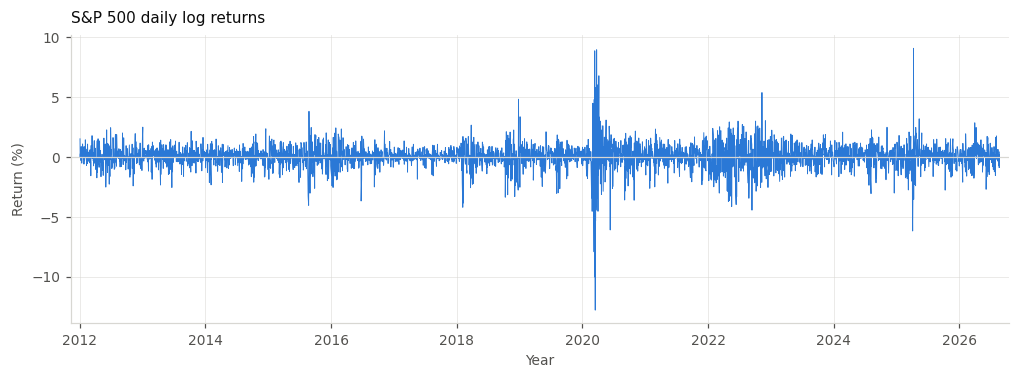

In [12]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(df.index, df["ret"], color=BLUE, linewidth=0.6)
ax.axhline(0, color=GRID, linewidth=0.8)
finish(ax, "S&P 500 daily log returns", "Return (%)")
fig.savefig(FIG_DIR / "fig2_returns.png"); plt.show()

Returns oscillate around zero with no visible trend, consistent with the ADF
result in Section 4. What is visible is that the *amplitude* is not constant:
calm stretches of small moves alternate with turbulent stretches of large moves in
both directions. Large changes cluster with large changes and small with small —
the defining signature of volatility clustering, and the phenomenon GARCH exists
to model.

### Figure 3 — Squared S&P 500 returns

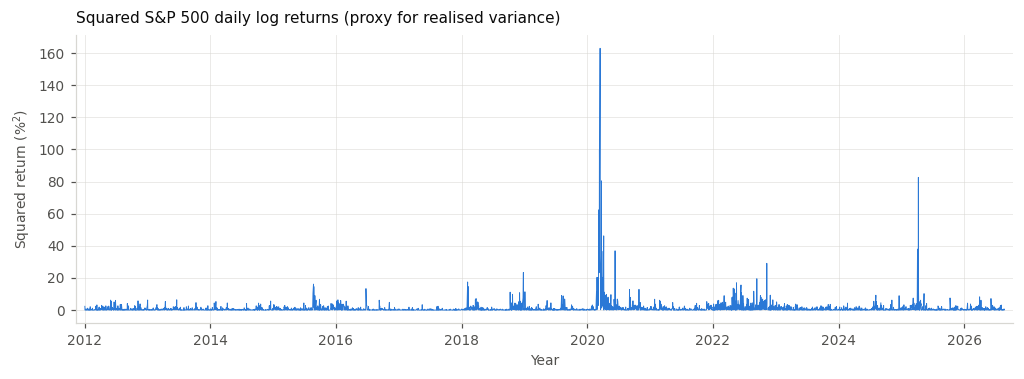

In [13]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(df.index, df["ret"]**2, color=BLUE, linewidth=0.6)
finish(ax, "Squared S&P 500 daily log returns (proxy for realised variance)",
       "Squared return (%$^2$)")
fig.savefig(FIG_DIR / "fig3_squared_returns.png"); plt.show()

Squaring removes the sign and leaves magnitude alone, which makes the clustering
unmistakable. The bursts line up with the VIX spikes in Figure 1 — the same
episodes, seen through realised rather than implied volatility. That visual
correspondence is the whole premise of the project; Section 6 measures it.

## 4. Time-series properties

### 4.1 Persistence of VIX

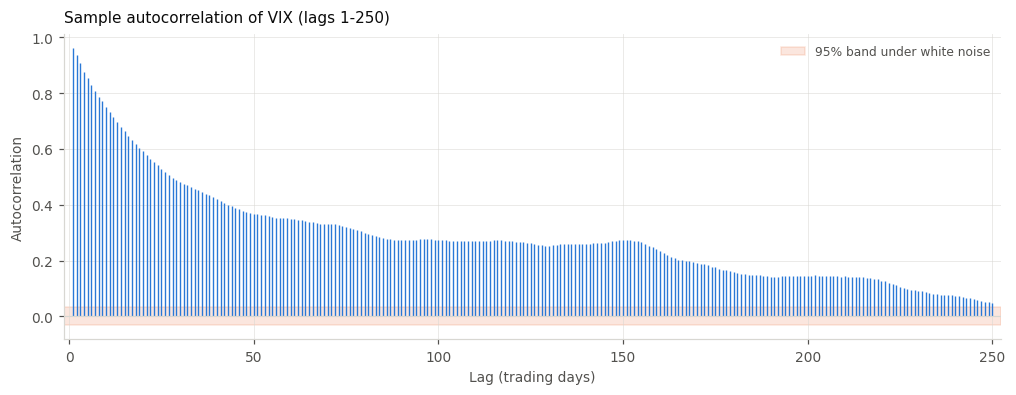

Autocorrelation of VIX at selected lags
  lag    1 : 0.9612
  lag    5 : 0.8537
  lag   10 : 0.7512
  lag   22 : 0.5627
  lag   66 : 0.3367
  lag  125 : 0.2619
  lag  250 : 0.0461

95% band = +/-0.0323
ACF remains outside the band as far as lag 250 of 250


In [14]:
from statsmodels.tsa.stattools import adfuller, acf

NLAGS = 250
acf_vix = acf(df["VIX"], nlags=NLAGS, fft=True)
band = 1.96 / np.sqrt(len(df))

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.vlines(range(1, NLAGS + 1), 0, acf_vix[1:], color=BLUE, linewidth=0.9)
ax.axhspan(-band, band, color=ORANGE, alpha=0.16, zorder=0,
           label="95% band under white noise")
ax.axhline(0, color=GRID, linewidth=0.8)
finish(ax, f"Sample autocorrelation of VIX (lags 1-{NLAGS})",
       "Autocorrelation", "Lag (trading days)")
ax.legend(loc="upper right", frameon=False, fontsize=8, labelcolor=INK_SOFT)
fig.savefig(FIG_DIR / "fig4_acf_vix.png"); plt.show()

print("Autocorrelation of VIX at selected lags")
for L in [1, 5, 10, 22, 66, 125, 250]:
    print(f"  lag {L:4d} : {acf_vix[L]:.4f}")
outside = np.where(np.abs(acf_vix[1:]) > band)[0] + 1
print(f"\n95% band = +/-{band:.4f}")
print(f"ACF remains outside the band as far as lag {outside.max()} of {NLAGS}")

**VIX is highly persistent.** The first-order autocorrelation is 0.96, still 0.56
after a month of trading (lag 22) and 0.34 after a quarter (lag 66). The
autocorrelation function remains outside the white-noise band all the way to lag
250 — a full trading year — and decays hyperbolically rather than geometrically.

This is precisely the long-memory behaviour Fernandes et al. (2014) document, and
their explanation applies here: VIX is a 30-calendar-day forward-looking measure
sampled *daily*, so consecutive observations refer to heavily overlapping windows.
That overlap mechanically induces persistence. It is also why their plain HAR
model is so hard to beat at short horizons, and why Wen et al. (2024) find that
lengthening the lag window keeps improving R² with no plateau at 20 days.

For this project the implication is direct: **any variable proposed as an
additional predictor of VIX — GARCH volatility included — has to add information
beyond an own-history baseline that is already extremely strong.**

### 4.2 Stationarity — Augmented Dickey–Fuller test

In [15]:
def adf_report(series, label, regression="c"):
    stat, p, lags, nobs, crit, _ = adfuller(series, regression=regression, autolag="AIC")
    print(f"{label}")
    print(f"   ADF statistic : {stat:.4f}")
    print(f"   p-value       : {p:.3e}")
    print(f"   lags (AIC)    : {lags}      observations: {nobs:,}")
    print("   critical      : " + "  ".join(f"{k} {v:.3f}" for k, v in crit.items()))
    print(f"   -> {'reject' if p < 0.01 else 'cannot reject'} the unit root null at 1%\n")

adf_report(df["VIX"],         "VIX (level, constant)")
adf_report(np.log(df["VIX"]), "log(VIX) (constant)  - the specification used by Fernandes et al.")
adf_report(df["ret"],         "S&P 500 returns (constant)")

VIX (level, constant)
   ADF statistic : -5.5602
   p-value       : 1.548e-06
   lags (AIC)    : 26      observations: 3,653
   critical      : 1% -3.432  5% -2.862  10% -2.567
   -> reject the unit root null at 1%



/tmp/ipykernel_1840/2931425217.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, p, lags, nobs, crit, _ = adfuller(series, regression=regression, autolag="AIC")
/tmp/ipykernel_1840/2931425217.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, p, lags, nobs, crit, _ = adfuller(series, regression=regression, autolag="AIC")


log(VIX) (constant)  - the specification used by Fernandes et al.
   ADF statistic : -5.9429
   p-value       : 2.240e-07
   lags (AIC)    : 8      observations: 3,671
   critical      : 1% -3.432  5% -2.862  10% -2.567
   -> reject the unit root null at 1%



S&P 500 returns (constant)
   ADF statistic : -13.4199
   p-value       : 4.210e-25
   lags (AIC)    : 25      observations: 3,654
   critical      : 1% -3.432  5% -2.862  10% -2.567
   -> reject the unit root null at 1%



/tmp/ipykernel_1840/2931425217.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, p, lags, nobs, crit, _ = adfuller(series, regression=regression, autolag="AIC")


The unit-root null is rejected decisively for VIX (ADF = −5.56, p ≈ 1.5 × 10⁻⁶),
for log(VIX), and for returns. VIX is therefore **stationary but strongly
persistent** — exactly the combination Fernandes et al. report. The two findings
are not in tension: stationarity says shocks eventually die out, while the ACF
says they take a very long time to do so.

Note that p-values are printed in scientific notation deliberately. Under the
notebook's global float format they would display as `0.0000`, which hides the
difference between a marginal rejection and one this emphatic.

### 4.3 Volatility clustering in returns

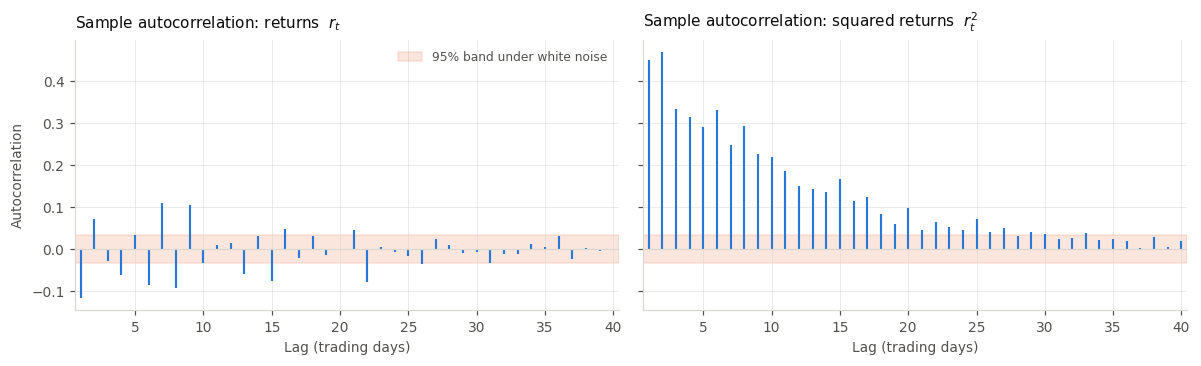

  lag    ACF r_t   ACF r_t^2
    1    -0.1164     +0.4494
    2    +0.0720     +0.4694
    3    -0.0282     +0.3328
    5    +0.0343     +0.2902
   10    -0.0340     +0.2184
   22    -0.0775     +0.0652


In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

L = 40
acf_ret = acf(df["ret"],    nlags=L, fft=True)
acf_sq  = acf(df["ret"]**2, nlags=L, fft=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, a, title in [(axes[0], acf_ret, "Sample autocorrelation: returns  $r_t$"),
                     (axes[1], acf_sq,  "Sample autocorrelation: squared returns  $r_t^2$")]:
    ax.vlines(range(1, L + 1), 0, a[1:], color=BLUE, linewidth=1.4)
    ax.axhspan(-band, band, color=ORANGE, alpha=0.16, zorder=0,
               label="95% band under white noise")
    ax.axhline(0, color=GRID, linewidth=0.8)
    finish(ax, title, "Autocorrelation" if ax is axes[0] else "", "Lag (trading days)")
axes[0].legend(loc="upper right", frameon=False, fontsize=8, labelcolor=INK_SOFT)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_acf_returns.png"); plt.show()

print(f"{'lag':>5} {'ACF r_t':>10} {'ACF r_t^2':>11}")
for k in [1, 2, 3, 5, 10, 22]:
    print(f"{k:5d} {acf_ret[k]:+10.4f} {acf_sq[k]:+11.4f}")

In [17]:
print("Ljung-Box test  (H0: no autocorrelation up to lag h)")
for name, s in [("returns", df["ret"]), ("squared returns", df["ret"]**2)]:
    lb = acorr_ljungbox(s, lags=[10, 22], return_df=True)
    for lag, row in lb.iterrows():
        print(f"   {name:16s} h={lag:3d}:  Q = {row['lb_stat']:10.2f}   p = {row['lb_pvalue']:.3e}")

print("\nEngle ARCH-LM test  (H0: no ARCH effects in returns)")
for lag in [5, 10, 22]:
    lm, lm_p, _, _ = het_arch(df["ret"], nlags=lag)
    print(f"   lags = {lag:3d}:  LM = {lm:10.2f}   p = {lm_p:.3e}")

Ljung-Box test  (H0: no autocorrelation up to lag h)
   returns          h= 10:  Q =     236.35   p = 3.999e-45
   returns          h= 22:  Q =     320.39   p = 8.782e-55
   squared returns  h= 10:  Q =    3955.26   p = 0.000e+00
   squared returns  h= 22:  Q =    4613.83   p = 0.000e+00

Engle ARCH-LM test  (H0: no ARCH effects in returns)
   lags =   5:  LM =    1108.71   p = 1.736e-237
   lags =  10:  LM =    1172.89   p = 1.015e-245
   lags =  22:  LM =    1208.32   p = 7.499e-242


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


**Returns show strong volatility clustering.** The contrast between the two panels
is the entire point:

| Lag | ACF of $r_t$ | ACF of $r_t^2$ |
|---:|---:|---:|
| 1 | −0.116 | **+0.449** |
| 2 | +0.072 | **+0.469** |
| 5 | +0.034 | **+0.290** |
| 10 | −0.034 | **+0.218** |
| 22 | −0.078 | **+0.065** |

Raw returns are close to unforecastable — the autocorrelations are small and
alternate in sign, as market efficiency would suggest. Squared returns are
emphatically not: the autocorrelation is 0.45 at lag 1, still 0.22 after two
weeks, and positive throughout. The *direction* of tomorrow's move is essentially
unpredictable; its *magnitude* is highly predictable from recent magnitudes.

Both formal tests agree. Ljung–Box on squared returns gives Q(10) = 3,955 against
Q(10) = 236 for raw returns — an order of magnitude larger on the same statistic.
Engle's ARCH-LM test returns LM = 1,109 at five lags with p ≈ 10⁻²³⁷.

This is the empirical precondition for GARCH. A model in which today's conditional
variance depends on yesterday's variance and yesterday's squared shock is not an
arbitrary choice here — it is the natural description of what Figures 2, 3 and 5
show.

## 5. Estimating GARCH(1,1)

The model for the conditional variance of S&P 500 returns is

$$r_t = \mu + \epsilon_t, \qquad \epsilon_t = \sigma_t z_t, \qquad
\sigma_t^2 = \omega + \alpha\,\epsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$$

Today's variance is a weighted combination of a long-run level ($\omega$), the
size of yesterday's surprise ($\alpha\epsilon_{t-1}^2$), and yesterday's variance
($\beta\sigma_{t-1}^2$). The ARCH-LM and Ljung–Box results in Section 4.3
establish that this structure is warranted.

Returns are already scaled by 100, which keeps the likelihood well conditioned.
The mean equation is a constant and the baseline error distribution is Gaussian —
the "basic" specification. A Student-t alternative is estimated afterwards as a
robustness check.

In [18]:
from arch import arch_model

model = arch_model(df["ret"], mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
res = model.fit(disp="off")
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4606.87
Distribution:                  Normal   AIC:                           9221.74
Method:            Maximum Likelihood   BIC:                           9246.59
                                        No. Observations:                 3680
Date:                Wed, Sep 02 2026   Df Residuals:                     3679
Time:                        17:14:42   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0788  1.217e-02      6.473  9.632e-11 [5.491e-0

In [19]:
w  = res.params["omega"]
al = res.params["alpha[1]"]
be = res.params["beta[1]"]
persistence = al + be

params = pd.DataFrame({
    "Estimate":   [res.params[k]   for k in ["mu", "omega", "alpha[1]", "beta[1]"]],
    "Std. error": [res.std_err[k]  for k in ["mu", "omega", "alpha[1]", "beta[1]"]],
    "t-statistic":[res.tvalues[k]  for k in ["mu", "omega", "alpha[1]", "beta[1]"]],
}, index=["mu (mean)", "omega", "alpha", "beta"])
display(params)

for k in ["omega", "alpha[1]", "beta[1]"]:
    print(f"p-value {k:9s}: {res.pvalues[k]:.3e}")

half_life = np.log(0.5) / np.log(persistence)
lr_var    = w / (1 - persistence)
lr_ann    = np.sqrt(lr_var) * np.sqrt(252)

print(f"\nalpha + beta                 : {persistence:.4f}")
print(f"Half-life of a variance shock: {half_life:.1f} trading days")
print(f"Long-run daily variance      : {lr_var:.4f}   (daily sd {np.sqrt(lr_var):.4f}%)")
print(f"Long-run annualised volatility: {lr_ann:.2f}")
print(f"Sample mean of VIX           : {df['VIX'].mean():.2f}")

,Estimate,Std. error,t-statistic
mu (mean),0.0788,0.0122,6.4726
omega,0.0431,0.0093,4.6333
alpha,0.1666,0.0230,7.2385
beta,0.7907,0.0256,30.9188


p-value omega    : 3.599e-06
p-value alpha[1] : 4.538e-13
p-value beta[1]  : 6.667e-210

alpha + beta                 : 0.9573
Half-life of a variance shock: 15.9 trading days
Long-run daily variance      : 1.0101   (daily sd 1.0050%)
Long-run annualised volatility: 15.95
Sample mean of VIX           : 17.75


### Interpretation

**$\omega = 0.0431$** is the constant floor of the variance equation. On its own it
is not directly interpretable; combined with the persistence it implies a long-run
daily variance of $\omega/(1-\alpha-\beta) = 1.010$, i.e. a daily standard
deviation of 1.005% and an annualised long-run volatility of **15.95** — close to
the sample standard deviation of returns (1.051%), as it should be.

**$\alpha = 0.167$** is the reaction coefficient: the weight on yesterday's squared
shock. A large unexpected move raises today's variance by 16.7% of that squared
surprise. This governs how sharply the model responds to news.

**$\beta = 0.791$** is the persistence coefficient: the weight carried over from
yesterday's variance. It is by far the most precisely estimated parameter
(t = 30.9) and it dominates the dynamics — volatility today is mostly volatility
yesterday.

**$\alpha + \beta = 0.957$** is the key quantity. It measures how long a shock to
variance survives. At 0.957 the process is stationary (the sum is below one, so
variance is mean-reverting and the long-run level exists) but **highly
persistent**: the half-life of a variance shock is

$$\frac{\ln 0.5}{\ln 0.957} \approx 15.9 \text{ trading days}$$

so it takes about three trading weeks for half of a volatility shock to dissipate.
This is the standard finding for daily equity index returns, where $\alpha+\beta$
is typically estimated between 0.95 and 0.99, and it mirrors the persistence
already documented for VIX in Section 4.1. Both the implied and the model-based
measure of volatility are slow-moving.

All three variance parameters are significant at any conventional level, and
$\alpha, \beta > 0$ with $\alpha + \beta < 1$, so the non-negativity and
stationarity conditions are satisfied.

### Robustness: Student-t errors

Section 2 found return kurtosis of 19.3, so the Gaussian assumption is
questionable. Re-estimating with Student-t innovations checks whether the
persistence result depends on it.

In [20]:
res_t = arch_model(df["ret"], mean="Constant", vol="GARCH", p=1, q=1,
                   dist="t").fit(disp="off")

compare = pd.DataFrame({
    "Normal":    [res.params["omega"],   res.params["alpha[1]"],   res.params["beta[1]"],
                  res.params["alpha[1]"] + res.params["beta[1]"],
                  res.loglikelihood, res.bic, np.nan],
    "Student-t": [res_t.params["omega"], res_t.params["alpha[1]"], res_t.params["beta[1]"],
                  res_t.params["alpha[1]"] + res_t.params["beta[1]"],
                  res_t.loglikelihood, res_t.bic, res_t.params["nu"]],
}, index=["omega", "alpha", "beta", "alpha + beta",
          "Log-likelihood", "BIC", "nu (d.o.f.)"])
display(compare)

,Normal,Student-t
omega,0.0431,0.0275
alpha,0.1666,0.1668
beta,0.7907,0.8172
alpha + beta,0.9573,0.9839
Log-likelihood,"-4,606.8719","-4,488.9366"
BIC,"9,246.5865","9,018.9265"
nu (d.o.f.),NaN,5.4824


The qualitative conclusion is unchanged: $\alpha$ is almost identical (0.167 both
ways) and the process remains stationary and highly persistent, with
$\alpha+\beta$ rising from 0.957 to 0.984. The estimated degrees of freedom,
$\nu = 5.5$, confirms strongly fat-tailed innovations, and BIC prefers the
Student-t specification decisively (9,019 against 9,247).

The Gaussian model is retained for the remainder of this stage because the brief
specifies a basic GARCH(1,1), and because the conditional volatility series the
two produce are very close. The Student-t result is the one to carry forward if a
single specification has to be defended later.

## 6. Conditional volatility and annualisation

`arch` returns $\sigma_t$ in the units of the input series — daily percent. VIX is
quoted as an annualised percentage volatility, so the two are put on a common
footing by scaling with the square root of the number of trading days in a year:

$$\sigma_{\text{annual}} = \sigma_{\text{daily}} \times \sqrt{252}$$

This is what makes a direct comparison meaningful, and it is why the overlay in
Section 7 needs only **one** vertical axis.

In [21]:
df["garch_vol_daily"] = res.conditional_volatility
df["garch_vol_ann"]   = df["garch_vol_daily"] * np.sqrt(252)

summary = pd.DataFrame({
    "Annualised GARCH volatility": describe(df["garch_vol_ann"]),
    "VIX":                         describe(df["VIX"]),
}).T[["N", "Mean", "Median", "Std. dev", "Minimum", "Maximum", "Skewness"]]
display(summary)

,N,Mean,Median,Std. dev,Minimum,Maximum,Skewness
Annualised GARCH volatility,"3,680.0000",14.5565,12.4776,7.8658,7.4526,119.9861,5.2356
VIX,"3,680.0000",17.7459,16.1800,6.4710,9.1400,82.6900,2.8631


## 7. How closely do VIX and GARCH volatility move together?

### Figure 6 — annualised GARCH volatility and VIX

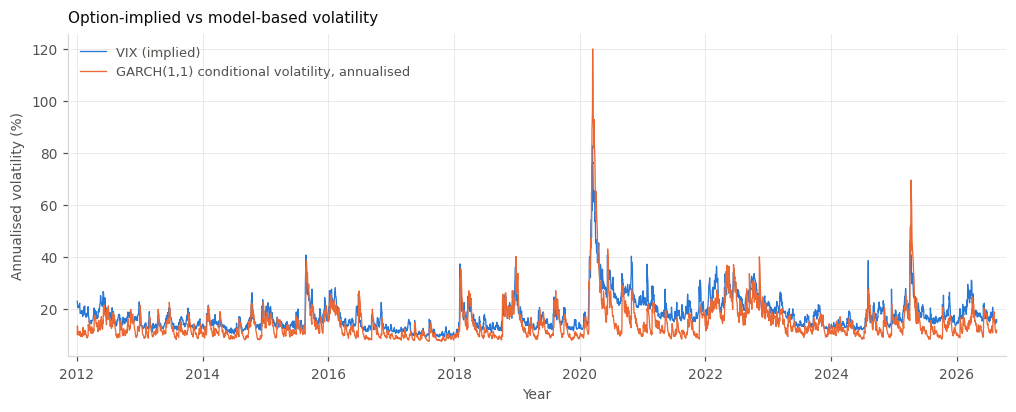

In [22]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(df.index, df["VIX"],           color=BLUE,   linewidth=0.85, label="VIX (implied)")
ax.plot(df.index, df["garch_vol_ann"], color=ORANGE, linewidth=0.85,
        label="GARCH(1,1) conditional volatility, annualised")
finish(ax, "Option-implied vs model-based volatility", "Annualised volatility (%)")
ax.legend(loc="upper left", frameon=False, fontsize=8.5, labelcolor=INK_SOFT)
fig.savefig(FIG_DIR / "fig6_vix_vs_garch.png"); plt.show()

Both series trace the same episodes — 2015, early 2018, March 2020, 2022 — and
spend the calm stretches in the same region. Two differences stand out. VIX sits
**above** the GARCH series almost all the time, and in March 2020 the GARCH line
overshoots far past VIX, reaching 120 against VIX's peak of 82.7. Both are
examined below.

In [23]:
df["gap"] = df["VIX"] - df["garch_vol_ann"]

print(f"Mean VIX                       : {df['VIX'].mean():.3f}")
print(f"Mean annualised GARCH vol      : {df['garch_vol_ann'].mean():.3f}")
print(f"Mean gap (VIX - GARCH)         : {df['gap'].mean():.3f} volatility points")
print(f"   as a share of GARCH mean    : {100*df['gap'].mean()/df['garch_vol_ann'].mean():.1f}%")
print(f"Median gap                     : {df['gap'].median():.3f}")
print(f"Days with VIX > GARCH          : {(df['gap']>0).sum():,} of {len(df):,} "
      f"({100*(df['gap']>0).mean():.2f}%)")
print(f"\nLargest GARCH overshoot        : {df['gap'].min():.2f} on {df['gap'].idxmin().date()}")
print(f"GARCH maximum                  : {df['garch_vol_ann'].max():.2f} on "
      f"{df['garch_vol_ann'].idxmax().date()}")
print(f"Worst single return in sample  : {df['ret'].min():.2f}% on {df['ret'].idxmin().date()}")

Mean VIX                       : 17.746
Mean annualised GARCH vol      : 14.557
Mean gap (VIX - GARCH)         : 3.189 volatility points
   as a share of GARCH mean    : 21.9%
Median gap                     : 3.074
Days with VIX > GARCH          : 3,190 of 3,680 (86.68%)

Largest GARCH overshoot        : -44.08 on 2020-03-17
GARCH maximum                  : 119.99 on 2020-03-17
Worst single return in sample  : -12.77% on 2020-03-16


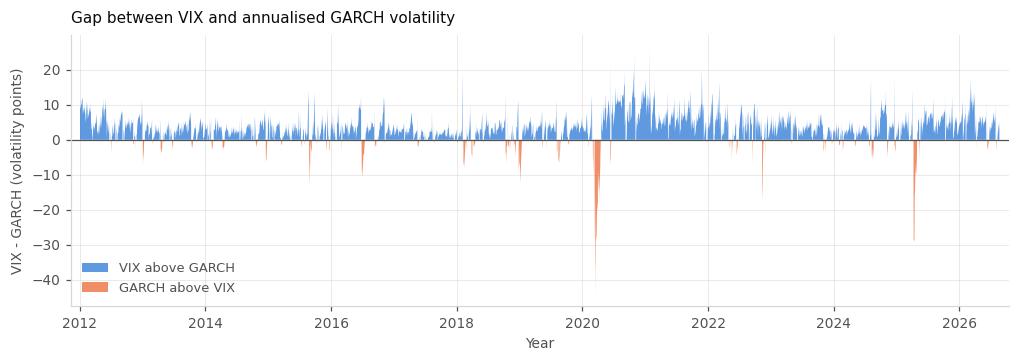

In [24]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.fill_between(df.index, 0, df["gap"], where=df["gap"] >= 0,
                color=BLUE, alpha=0.75, linewidth=0, label="VIX above GARCH")
ax.fill_between(df.index, 0, df["gap"], where=df["gap"] < 0,
                color=ORANGE, alpha=0.75, linewidth=0, label="GARCH above VIX")
ax.axhline(0, color=INK_SOFT, linewidth=0.8)
finish(ax, "Gap between VIX and annualised GARCH volatility",
       "VIX - GARCH (volatility points)")
ax.legend(loc="lower left", frameon=False, fontsize=8.5, labelcolor=INK_SOFT)
fig.savefig(FIG_DIR / "fig7_gap.png"); plt.show()

### The gap is systematic, not noise

VIX exceeds the annualised GARCH volatility on **86.7%** of days, by an average of
**3.19 volatility points — about 22% of the GARCH mean**. A gap that one-sided is
not an estimation error; it is the **variance risk premium**. VIX is a
*risk-neutral* expectation extracted from option prices, so it embeds compensation
that investors demand for bearing volatility risk, on top of the physical
forecast. GARCH, estimated from realised returns alone, delivers only the physical
forecast.

Liu, Guo & Qiao (2015) document the same shortfall and interpret it the same way:
their GARCH-computed VIX ran 20–30% below the market VIX before September 2003 and
10–13% below afterwards. Our 22% is larger than that post-2003 figure, which is the
relevant benchmark for a 2012–2026 sample. Two differences plausibly account for the
gap — they compare a one-day-ahead GARCH *forecast of VIX* against the market VIX,
whereas we compare annualised conditional volatility against VIX, and the sample
periods do not overlap.

The exception is instructive. The GARCH series exceeds VIX on 13.3% of days, and
the largest overshoot — 44 points on **17 March 2020** — comes directly after the
−12.77% crash of 16 March. Because $\sigma_t^2$ depends on $\epsilon_{t-1}^2$, a
single enormous return is mechanically propagated into the next day's variance,
pushing annualised GARCH volatility to 120 while VIX, which is forward-looking and
already pricing an eventual return to calm, stood at 75.9. GARCH extrapolates the
recent past; VIX anticipates.

### Correlation

In [25]:
lv = df["garch_vol_ann"].corr(df["VIX"])
sp = df["garch_vol_ann"].corr(df["VIX"], method="spearman")
lg = np.log(df["garch_vol_ann"]).corr(np.log(df["VIX"]))

print("Levels")
print(f"   Pearson  : {lv:.4f}")
print(f"   Spearman : {sp:.4f}")
print(f"   log-log  : {lg:.4f}")

d_g, d_v = df["garch_vol_ann"].diff(), df["VIX"].diff()
print(f"\nDaily changes")
print(f"   Pearson  : {d_g.corr(d_v):.4f}")

print("\nLead-lag: GARCH change at t+k against VIX change at t")
for k in range(-2, 4):
    print(f"   k = {k:+d} : {d_g.shift(-k).corr(d_v):+.4f}")

print("\nLevels correlation by sub-period")
for lo, hi in [(2012, 2015), (2016, 2019), (2020, 2022), (2023, 2026)]:
    m = (df.index.year >= lo) & (df.index.year <= hi)
    print(f"   {lo}-{hi} : {df.loc[m, 'garch_vol_ann'].corr(df.loc[m, 'VIX']):+.4f}")

Levels
   Pearson  : 0.8331
   Spearman : 0.7301
   log-log  : 0.7932

Daily changes
   Pearson  : -0.0071

Lead-lag: GARCH change at t+k against VIX change at t
   k = -2 : +0.0015
   k = -1 : +0.0263
   k = +0 : -0.0071
   k = +1 : +0.4100
   k = +2 : +0.0348
   k = +3 : +0.1066

Levels correlation by sub-period
   2012-2015 : +0.6626
   2016-2019 : +0.8032
   2020-2022 : +0.8888
   2023-2026 : +0.6992


**In levels the two move together closely — Pearson 0.83, Spearman 0.73, 0.79 in
logs.** Across four-year sub-periods the level correlation ranges from 0.66 to 0.89 —
strongest in the turbulent 2020–2022 window, weakest in the calm stretches — which is
what one expects when both series are compressed into a narrow range.

**In daily changes the correlation collapses to −0.007 — effectively zero.** That
looks contradictory but is not, and the lead-lag profile explains it:

| $k$ | −2 | −1 | 0 | **+1** | +2 |
|---|---:|---:|---:|---:|---:|
| corr($\Delta$GARCH$_{t+k}$, $\Delta$VIX$_t$) | +0.00 | +0.03 | −0.01 | **+0.41** | +0.03 |

The correlation is near zero contemporaneously and **+0.41 at a one-day lag**. The
reason is structural: $\sigma_t$ is a function of information dated $t-1$, so the
GARCH series cannot respond to today's news until tomorrow, whereas VIX is priced
off today's option quotes and responds immediately. The two measures agree about
the *level* of volatility, but GARCH learns about changes exactly one day after
the options market has already priced them.

**This is the single most important result of Stage 2 for what follows.** A
predictor that merely tracked VIX would be redundant. GARCH volatility does not:
it is strongly related in levels, reacts on a different schedule, and carries a
systematic risk-premium wedge that VIX contains and GARCH cannot. Whether any of
that survives as *incremental* forecasting power once VIX's own history is
conditioned on is the question Stage 3 exists to answer — and Section 4.1 already
shows the baseline is a demanding one.

## 8. Summary answers

**Is VIX highly persistent?**
Yes, and strongly so. First-order autocorrelation is 0.961, still 0.563 after a
month and 0.337 after a quarter, and the ACF stays outside the white-noise band as
far as lag 250 — a full trading year. Decay is hyperbolic rather than geometric,
the long-memory pattern Fernandes et al. (2014) document. VIX is nonetheless
stationary: ADF = −5.56 with p = 1.5 × 10⁻⁶, so the unit-root null is rejected
decisively. Persistent but mean-reverting.

**Is there volatility clustering in S&P 500 returns?**
Yes, unambiguously. Raw returns are close to unforecastable (first-order
autocorrelation −0.116, small and alternating thereafter), but squared returns are
autocorrelated at 0.449 at lag 1 and remain positive past lag 20. Ljung–Box on
squared returns gives Q(10) = 3,955 against 236 for raw returns, and Engle's
ARCH-LM test returns LM = 1,109 with p ≈ 10⁻²³⁷. Figures 2 and 3 show it directly:
large moves cluster with large moves.

**Is GARCH volatility highly persistent?**
Yes. $\alpha + \beta = 0.957$, implying a half-life of about 15.9 trading days for
a variance shock — roughly three trading weeks to decay by half. The sum is below
one, so the process is stationary with a long-run annualised volatility of 15.95,
close to the sample standard deviation of returns. With Student-t errors
persistence rises to 0.984, so the conclusion does not depend on the distributional
assumption.

**How closely do VIX and GARCH volatility move together?**
Closely in levels, hardly at all in daily changes. Pearson correlation in levels is
0.83 (Spearman 0.73), ranging from 0.66 to 0.89 across four-year sub-periods and
highest during 2020–2022. In first differences it is −0.007. The lead-lag profile resolves the
apparent conflict: the correlation between the GARCH change at $t+1$ and the VIX
change at $t$ is +0.41. GARCH responds to the same information one day later,
because $\sigma_t$ conditions on data through $t-1$ while VIX is priced off
current quotes.

**What is the main difference between VIX and GARCH volatility?**
They are different objects, not competing estimates of the same one.

*Direction of information.* VIX is forward-looking, extracted from option prices
and expressing the market's expectation of volatility over the coming 30 calendar
days. GARCH volatility is backward-looking, computed mechanically from the history
of realised returns.

*Measure.* VIX is risk-neutral and therefore includes a variance risk premium —
compensation for bearing volatility risk. GARCH is a physical-measure forecast and
includes no such premium. This is visible in the data: VIX exceeds annualised GARCH
volatility on 86.7% of days, by an average of 3.19 points or about 22% — the same
phenomenon Liu et al. (2015) report, though larger than their post-2003 figure of
10–13%, which is the relevant benchmark for this sample.

*Timing.* VIX reprices within the trading day; GARCH cannot move until the day
after a shock. Hence the one-day lag in the change correlation, and hence the March
2020 episode, where GARCH extrapolated the −12.77% crash to an annualised 120 while
VIX, anticipating eventual normalisation, peaked at 82.7.

In [26]:
df.to_csv(DATA_DIR / "stage2_final.csv")
print(f"Saved {DATA_DIR / 'stage2_final.csv'}   ({len(df):,} rows, {df.shape[1]} columns)")
print("Columns:", list(df.columns))
display(df.head(3))

Saved stage2_final.csv   (3,680 rows, 6 columns)
Columns: ['SP500', 'VIX', 'ret', 'garch_vol_daily', 'garch_vol_ann', 'gap']


,SP500,VIX,ret,garch_vol_daily,garch_vol_ann,gap
Date,,,,,,
2012-01-03,"1,277.0601",22.9700,1.5355,0.6378,10.1251,12.8449
2012-01-04,"1,277.3000",22.2200,0.0188,0.8476,13.4545,8.7655
2012-01-05,"1,281.0601",21.4800,0.2939,0.7821,12.4159,9.0641
